In [1]:
# Import nessessary libraries
from sklearn.datasets import fetch_california_housing
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
import time 

In [2]:
# Load dataset
housing = fetch_california_housing()

dir(housing)

['DESCR', 'data', 'feature_names', 'frame', 'target', 'target_names']

In [3]:
housing.target

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [4]:
housing.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [5]:
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [6]:
df["MedHouseVal"] = housing.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
df.shape

(20640, 9)

In [8]:
df.isnull().sum() # No null values 

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [9]:
df.describe() # Outliers are present

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [10]:
# Let's treat them using IQR method
q1 = df["AveRooms"].quantile(0.25)
q3 = df["AveRooms"].quantile(0.75)

IQR = q3 - q1

q1, q3, IQR

(4.440716235896959, 6.052380952380952, 1.6116647164839932)

In [11]:
lower = q1 - 3 * IQR
upper = q3 + 3 * IQR

lower, upper # We need upper limit only 

(-0.39427791355502073, 10.887375101832932)

In [12]:
df[df["AveRooms"]>upper] # These are outliers

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
1024,3.1500,16.0,29.852941,5.323529,202.0,1.980392,38.52,-120.00,1.406
1102,2.4028,17.0,31.777778,9.703704,47.0,1.740741,40.06,-121.54,0.675
1233,3.7500,10.0,16.847534,3.237668,546.0,2.448430,38.23,-120.34,1.214
1234,4.4063,13.0,28.757282,5.300971,252.0,2.446602,38.26,-120.33,1.558
1235,2.9821,17.0,13.473039,2.588235,997.0,2.443627,38.25,-120.34,1.115
...,...,...,...,...,...,...,...,...,...
20093,2.0625,37.0,24.669118,4.897059,338.0,2.485294,38.12,-120.12,0.889
20094,2.1250,26.0,37.063492,7.185185,416.0,2.201058,38.19,-120.03,1.325
20110,3.2589,9.0,11.458508,2.056161,2811.0,2.356245,37.84,-120.20,1.379
20112,4.0833,18.0,11.536585,2.804878,88.0,2.146341,37.85,-119.93,1.375


In [13]:
df = df[df["AveRooms"]<upper] 
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20460.000000,20460.000000,20460.000000,20460.000000,20460.000000,20460.000000,20460.000000,20460.000000,20460.000000
mean,3.870573,28.733724,5.286647,1.067957,1433.489883,3.075037,35.620380,-119.574112,2.071607
std,1.897046,12.572654,1.250305,0.135304,1133.101527,10.430994,2.129887,2.003353,1.154721
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.750000,32.540000,-124.350000,0.149990
25%,2.562500,18.000000,4.433962,1.005614,794.000000,2.433650,33.930000,-121.800000,1.198000
50%,3.534800,29.000000,5.217391,1.048000,1171.000000,2.824118,34.250000,-118.490000,1.804000
75%,4.746325,37.000000,6.023286,1.097687,1730.000000,3.286391,37.710000,-118.010000,2.653000
max,15.000100,52.000000,10.860423,3.411111,35682.000000,1243.333333,41.950000,-114.550000,5.000010


In [14]:
df.shape

(20460, 9)

<Axes: xlabel='Population', ylabel='Count'>

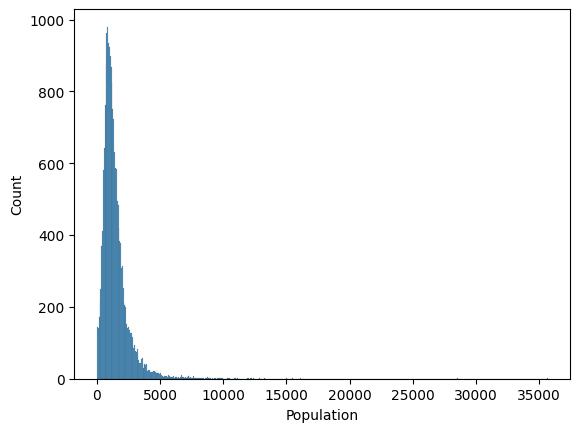

In [15]:
sns.histplot(df["Population"])

In [16]:
# Avg population column also has outliers let's treat them too
q1 = df["Population"].quantile(0.25)
q3 = df["Population"].quantile(0.75)

IQR = q3 - q1

lower = q1 - 3 * IQR
upper = q3 + 3 * IQR

df[df["Population"]>upper].head() # These are outliers

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
283,5.9849,22.0,6.528724,1.041179,4985.0,2.534316,37.79,-122.16,3.710
570,7.6110,5.0,6.855776,1.061442,7427.0,2.732524,37.72,-122.24,3.507
576,7.2634,12.0,7.133034,1.018934,5781.0,2.880419,37.77,-122.06,3.416
780,3.8171,18.0,5.119733,1.043679,5613.0,2.884378,37.63,-122.10,1.872
799,2.5158,22.0,4.006152,1.036227,5436.0,3.715653,37.64,-122.07,1.349


In [17]:
df = df[df["Population"]<upper]
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20039.000000,20039.000000,20039.000000,20039.000000,20039.000000,20039.000000,20039.000000,20039.000000,20039.000000
mean,3.864998,29.033335,5.282851,1.067844,1327.427666,2.966921,35.630577,-119.585940,2.073424
std,1.902785,12.463440,1.248369,0.136319,786.697307,4.350186,2.133224,2.004485,1.159368
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.750000,32.540000,-124.350000,0.149990
25%,2.557450,19.000000,4.433389,1.004721,786.000000,2.428571,33.930000,-121.810000,1.191000
50%,3.526800,29.000000,5.210744,1.047692,1156.000000,2.817259,34.260000,-118.500000,1.804000
75%,4.737100,37.000000,6.013970,1.097678,1685.000000,3.280000,37.710000,-118.020000,2.659000
max,15.000100,52.000000,10.860423,3.411111,4533.000000,599.714286,41.950000,-114.550000,5.000010


In [18]:
# Avg Occupation column also has outliers let's treat them too
q1 = df["AveOccup"].quantile(0.25)
q3 = df["AveOccup"].quantile(0.75)

IQR = q3 - q1

lower = q1 - 3 * IQR
upper = q3 + 3 * IQR

df[df["AveOccup"]>upper] # These are outliers

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
91,0.8668,52.0,2.443182,0.988636,904.0,10.272727,37.80,-122.28,1.37500
270,3.8750,33.0,3.021277,0.659574,575.0,12.234043,37.78,-122.18,2.25000
460,1.4012,52.0,3.105714,1.060000,3337.0,9.534286,37.87,-122.26,1.75000
1067,3.4191,52.0,4.530612,0.816327,1107.0,11.295918,39.73,-121.85,1.37500
1617,11.7064,17.0,9.361702,1.127660,1722.0,12.212766,37.84,-122.08,5.00001
...,...,...,...,...,...,...,...,...,...
20297,2.7250,32.0,5.992395,1.133080,3490.0,6.634981,34.15,-119.22,4.50000
20311,2.0368,37.0,5.662651,1.265060,522.0,6.289157,34.17,-119.11,2.43800
20324,3.5625,31.0,4.386905,0.869048,1436.0,8.547619,34.25,-119.12,1.94100
20352,4.0208,8.0,2.500000,0.625000,309.0,19.312500,34.22,-119.09,0.52500


In [19]:
df = df[df["AveOccup"]<upper]
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,19927.000000,19927.000000,19927.000000,19927.000000,19927.000000,19927.000000,19927.000000,19927.000000,19927.000000
mean,3.866949,29.027500,5.285813,1.067857,1326.514729,2.898742,35.631823,-119.587139,2.075039
std,1.899106,12.458493,1.246280,0.135790,784.194434,0.712964,2.133374,2.004599,1.159855
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.750000,32.540000,-124.350000,0.149990
25%,2.559200,19.000000,4.436037,1.004775,787.000000,2.427200,33.930000,-121.820000,1.190000
50%,3.528800,29.000000,5.213415,1.047703,1156.000000,2.812903,34.260000,-118.500000,1.806000
75%,4.740300,37.000000,6.017149,1.097561,1683.000000,3.270201,37.710000,-118.020000,2.662000
max,15.000100,52.000000,10.860423,3.411111,4533.000000,5.816254,41.950000,-114.550000,5.000010


In [20]:
# Define feature and target variable
X = df.drop("MedHouseVal", axis = 1)
y = df["MedHouseVal"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [21]:
# Linear Regression Model
start = time.time()
model = LinearRegression()
model.fit(X_train, y_train)
end = time.time()

y_pred = model.predict(X_test)

r2s_linear = r2_score(y_test, y_pred)
mse_linear = mean_squared_error(y_test, y_pred)

print(f"R2S : {r2s_linear}, MSE : {mse_linear}, time = {end-start}")

R2S : 0.6652759382201766, MSE : 0.4486223812848361, time = 0.005998849868774414


In [22]:
# Gradient Boosting Model
start = time.time()
model = GradientBoostingRegressor()
model.fit(X_train, y_train)
end = time.time()

y_pred = model.predict(X_test)

r2s_gb = r2_score(y_test, y_pred)
mse_gb = mean_squared_error(y_test, y_pred)

print(f"R2S : {r2s_gb}, MSE : {mse_gb}, time = {end-start}")

R2S : 0.787895946081876, MSE : 0.2842778175042206, time = 5.165193557739258


In [23]:
# XGBoost Model
start = time.time()
model = XGBRegressor()
model.fit(X_train, y_train)
end = time.time()

y_pred = model.predict(X_test)

r2s_xgb = r2_score(y_test, y_pred)
mse_xgb = mean_squared_error(y_test, y_pred)

print(f"R2S : {r2s_xgb}, MSE : {mse_xgb}, time = {end-start}")

R2S : 0.8405691641687271, MSE : 0.21368120606729796, time = 0.8228292465209961


As we can see XGBoost is giving better performance in shorter duration of model training.